# Simple DDPM on MNIST

`diffusion_ddpm.py`와 같은 내용을 Jupyter Notebook에서 단계별로 실행할 수 있게 나눈 버전입니다.

핵심 흐름: **schedule 정의 → noise predictor → forward diffusion → noise prediction 학습**

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1. Diffusion schedule

- `beta_t`: 각 timestep에서 추가되는 noise 정도
- `alpha_t = 1 - beta_t`
- `alpha_bar_t`: 0부터 현재 timestep까지의 누적 alpha

In [3]:
T = 1000

beta = torch.linspace(1e-4, 0.02, T)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

alpha_bar_device = alpha_bar.to(device)

print(beta.shape, alpha.shape, alpha_bar.shape)

torch.Size([1000]) torch.Size([1000]) torch.Size([1000])


## 2. Noise predictor

입력은 noisy image `x_t`와 timestep `t`, 출력은 이미지에 들어간 noise의 예측값입니다.

In [4]:
class DiffusionModel(nn.Module):
    def __init__(self, timesteps: int = T):
        super().__init__()

        self.time_embed = nn.Embedding(timesteps, 32)

        self.conv1 = nn.Conv2d(1 + 32, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x, t):
        # t: (B,) -> (B, 32)
        time = self.time_embed(t)

        # (B, 32) -> (B, 32, H, W)
        time = time[:, :, None, None]
        time = time.expand(-1, -1, x.shape[2], x.shape[3])

        # image 1 channel + time 32 channels = 33 channels
        x = torch.cat([x, time], dim=1)

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        # noise 자체를 회귀하므로 sigmoid 없음
        return self.conv3(x)

## 3. Forward diffusion

$$x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon$$

원본 이미지 `x0`에서 원하는 timestep `t`의 noisy image를 한 번에 만듭니다.

In [ ]:
def add_noise(x0, t, noise, alpha_bar_device):
    a_bar = alpha_bar_de  vice[t][:, None, None, None]

    xt = (
        torch.sqrt(a_bar) * x0
        + torch.sqrt(1.0 - a_bar) * noise
    )

    return xt

## 4. MNIST dataset

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

# Notebook에서는 multiprocessing 문제를 피하려고 num_workers=0 사용
dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

real_images, _ = next(iter(dataloader))
print("batch shape:", real_images.shape)

batch shape: torch.Size([128, 1, 28, 28])


## 5. Model and optimizer

In [7]:
model = DiffusionModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model

DiffusionModel(
  (time_embed): Embedding(1000, 32)
  (conv1): Conv2d(33, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

## 6. Training

각 이미지마다 랜덤 timestep을 고르고, 그 시점의 noisy image를 만든 뒤 모델이 실제 noise를 맞히도록 MSE로 학습합니다.

In [12]:
epochs = 5

for epoch in range(epochs):
    model.train()

    for step, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # 1) 이미지마다 랜덤 timestep 선택
        t = torch.randint(
            low=0,
            high=T,
            size=(batch_size,),
            device=device,
        )

        # 2) 정답이 될 Gaussian noise 생성
        noise = torch.randn_like(real_images)

        # 3) 원본 이미지에 해당 timestep 수준의 noise 추가
        noisy_images = add_noise(
            real_images,
            t,
            noise,
            alpha_bar_device,
        )

        # 4) 모델이 들어간 noise를 예측
        predicted_noise = model(noisy_images, t)

        # 5) 실제 noise와 예측 noise 비교
        loss = F.mse_loss(predicted_noise, noise)

        # 6) 모델 학습
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            print(
                f"epoch={epoch + 1}/{epochs} "
                f"step={step:04d} "
                f"loss={loss.item():.4f}"
            )

epoch=1/5 step=0000 loss=0.0508
epoch=1/5 step=0100 loss=0.0513
epoch=1/5 step=0200 loss=0.0529
epoch=1/5 step=0300 loss=0.0460
epoch=1/5 step=0400 loss=0.0410
epoch=2/5 step=0000 loss=0.0421
epoch=2/5 step=0100 loss=0.0470
epoch=2/5 step=0200 loss=0.0422
epoch=2/5 step=0300 loss=0.0488
epoch=2/5 step=0400 loss=0.0481
epoch=3/5 step=0000 loss=0.0427
epoch=3/5 step=0100 loss=0.0416
epoch=3/5 step=0200 loss=0.0449
epoch=3/5 step=0300 loss=0.0366
epoch=3/5 step=0400 loss=0.0371
epoch=4/5 step=0000 loss=0.0538
epoch=4/5 step=0100 loss=0.0457
epoch=4/5 step=0200 loss=0.0482
epoch=4/5 step=0300 loss=0.0398
epoch=4/5 step=0400 loss=0.0408
epoch=5/5 step=0000 loss=0.0358
epoch=5/5 step=0100 loss=0.0386
epoch=5/5 step=0200 loss=0.0486
epoch=5/5 step=0300 loss=0.0356
epoch=5/5 step=0400 loss=0.0463


## 7. Save model

In [ ]:
torch.save(model.state_dict(), "diffusion_mnist.pt")
print("saved: diffusion_mnist.pt")

In [ ]:
state = torch.load("diffusion_mnist.pt")
print(type(state))
model.load_state_dict(state)

<class 'collections.OrderedDict'>


<All keys matched successfully>

In [10]:
@torch.no_grad()
def sample(model, num_samples=16):
    model.eval()

    # 시작점: 순수 가우시안 노이즈 x_T
    x = torch.randn(num_samples, 1, 28, 28, device=device)

    for t in reversed(range(T)):
        t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)

        # 모델이 현재 x_t 안의 noise를 예측
        predicted_noise = model(x, t_batch)

        a_t = alpha[t].to(device)
        a_bar_t = alpha_bar[t].to(device)
        b_t = beta[t].to(device)

        # DDPM reverse step의 평균
        mean = (
            1 / torch.sqrt(a_t)
        ) * (
            x - (b_t / torch.sqrt(1 - a_bar_t)) * predicted_noise
        )

        # 마지막 step(t=0)이 아니면 stochastic noise 추가
        if t > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(b_t) * noise
        else:
            x = mean

    return x

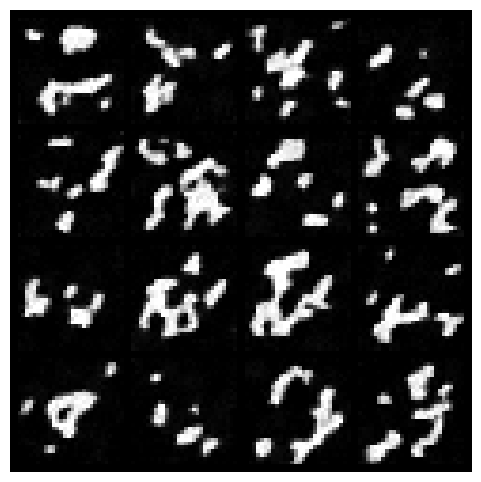

In [13]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

samples = sample(model, num_samples=16)

# [-1, 1] -> [0, 1]
samples = samples.clamp(-1, 1)
samples = (samples + 1) / 2

grid = make_grid(samples, nrow=4, padding=2)
grid = grid.permute(1, 2, 0).cpu()

plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.show()